# LIBRARIES

In [12]:
import random
from queue import Queue, PriorityQueue
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CLASSES

## MEASURES

In [13]:
class Measure:
    def __init__(self,Narr,Ndep,NAveraegUser,OldTimeEvent,AverageDelay):
        self.arr = Narr
        self.dep = Ndep
        self.ut = NAveraegUser
        self.oldT = OldTimeEvent
        self.delay = AverageDelay
        self.waiting_delay = 0  # Average waiting time in queue
        self.waiting_delays = []  # List of individual waiting delays
        self.buffer_occ = 0  # Average buffer occupancy (number of customers in queue)
        self.losses = 0  # Number of customers lost (rejected)
        self.busy_time = 0  # Cumulative busy time of the server

## CLIENT

In [14]:
class Client:
    def __init__(self,type,arrival_time):
        self.type = type
        self.arrival_time = arrival_time
        self.service_start_time = None  # When the service begins

## SERVER

In [15]:
class Server(object):

    # constructor
    def __init__(self, server_id):
        self.id = server_id
        # whether the server is idle or not
        self.idle = True
        self.busy_since = None  # Track when server became busy


# CONSTANT

In [16]:

SERVICE = 10.0 # SERVICE is the average service time; service rate = 1/SERVICE
# ARRIVALS: first three are ERGODIC (ρ < 1), fourth is NON-ERGODIC (ρ > 1)
ARRIVALS = [15, 12, 11, 5]  # ρ = [0.67, 0.83, 0.91, 2.0]
LOAD = [SERVICE/arrival for arrival in ARRIVALS] # This relationship holds for M/M/1

TYPE1 = 1 

NUM_SERVERS = 1  # Number of servers in the system (change this to simulate M/M/N)

BUFFER_SIZE = float('inf')  # Maximum buffer size for finite capacity queue

SIM_TIME = 500000

arrivals = 0
users = 0
servers = []  # Pool of servers - will be initialized before each simulation

MM1 = []


# FUNCTIONS

## ARRIVAL

In [17]:
def arrival(data,time, FES, queue, arr_time):
    global users
    
    #print("Arrival no. ",data.arr+1," at time ",time," with ",users," users" )
    
    # cumulate statistics
    data.ut += users*(time-data.oldT)
    data.buffer_occ += max(users - NUM_SERVERS, 0) * (time - data.oldT)  # queue length
    data.busy_time += (1 if users > 0 else 0) * (time - data.oldT)  # Busy time when at least one server is occupied
    data.oldT = time

    # sample the time until the next event
    inter_arrival = random.expovariate(lambd=1.0/arr_time)
        
    # schedule the next arrival
    FES.put((time + inter_arrival, "arrival"))

    # Check if buffer is full - if so, customer is lost
    if users >= BUFFER_SIZE:
        data.losses += 1
        return
    
    # Otherwise, accept the customer
    data.arr += 1
    users += 1
    
    # create a record for the client
    client = Client(TYPE1,time)

    # insert the record in the queue
    queue.append(client)

    # if there's an idle server, start the service immediately
    idle_server = next((s for s in servers if s.idle), None)
    if idle_server:
        # Mark the service start time for this client
        client.service_start_time = time
        idle_server.idle = False
        idle_server.busy_since = time
        
        # sample the service time
        service_time = random.expovariate(1.0/SERVICE)

        # schedule when the client will finish the server
        FES.put((time + service_time, "departure", idle_server.id))


## DEPARTURES

In [18]:
def departure(data,time, FES, queue, server_id):
    global users

    #print("Departure no. ",data.dep+1," at time ",time," with ",users," users" )
        
    # cumulate statistics
    data.dep += 1
    data.ut += users*(time-data.oldT)
    data.buffer_occ += max(users - NUM_SERVERS, 0) * (time - data.oldT)  # queue length
    data.busy_time += (1 if users > 0 else 0) * (time - data.oldT)  # Busy time when at least one server is occupied
    data.oldT = time
    
    # get the first element from the queue
    client = queue.pop(0)
    
    # do whatever we need to do when clients go away
    
    # Calculate total delay (system time)
    data.delay += (time-client.arrival_time)
    
    # Calculate waiting delay (time in queue before service)
    if client.service_start_time is not None:
        waiting_delay = client.service_start_time - client.arrival_time
        data.waiting_delay += waiting_delay
        data.waiting_delays.append(waiting_delay)
    
    users -= 1
    
    # Mark this server as idle
    server = servers[server_id]
    server.idle = True
    server.busy_since = None
    
    # see whether there are more clients in the queue
    if users > 0 and len(queue) > 0:
        # Find an idle server to serve the next client
        idle_server = next((s for s in servers if s.idle), None)
        if idle_server:
            # Mark the service start time for the next client
            next_client = queue[0]
            next_client.service_start_time = time
            idle_server.idle = False
            idle_server.busy_since = time
            
            # sample the service time
            service_time = random.expovariate(1.0/SERVICE)

            # schedule when the client will finish the server
            FES.put((time + service_time, "departure", idle_server.id))


## CONFIDENCE INTERVALS

In [19]:
def confidence_interval(data, confidence=0.95):
    
    n = len(data)
    mean = np.mean(data)
    std_err = st.sem(data)
    h = std_err * st.t.ppf((1 + confidence) / 2, n - 1)

    return mean, mean - h, mean + h

## REPORT

In [ ]:
def report(all_results, arrivals, service):
    """
    Print summary statistics for all scenarios
    
    Parameters:
    - all_results: dictionary containing results from get_results()
    - arrivals: list of arrival rates scenarios (ARRIVALS constant)
    - service: average service time (SERVICE constant)
    """
    for arrival_scenario in arrivals:
        results = all_results[arrival_scenario]
        
        print("=" * 60)
        print(f"RESULTS FROM 25 SIMULATIONS - ARRIVAL = {arrival_scenario}")
        print("=" * 60)
        
        print("\nNUMBER OF ARRIVALS:")
        mean, lower, upper = confidence_interval(results['arrivals'])
        print(f"  Mean: {mean:.2f}, CI[95%]: [{lower:.2f}, {upper:.2f}]")
        
        print("\nNUMBER OF DEPARTURES:")
        mean, lower, upper = confidence_interval(results['departures'])
        print(f"  Mean: {mean:.2f}, CI[95%]: [{lower:.2f}, {upper:.2f}]")
        
        print("\nAVERAGE NUMBER OF USERS IN SYSTEM:")
        mean, lower, upper = confidence_interval(results['avg_users'])
        print(f"  Mean: {mean:.4f}, CI[95%]: [{lower:.4f}, {upper:.4f}]")
        
        print("\nAVERAGE DELAY (total system time per customer):")
        mean, lower, upper = confidence_interval(results['avg_delay'])
        print(f"  Mean: {mean:.4f}, CI[95%]: [{lower:.4f}, {upper:.4f}]")
        
        print("\nAVERAGE WAITING DELAY (time in queue per customer):")
        mean, lower, upper = confidence_interval(results['avg_waiting_delay'])
        print(f"  Mean: {mean:.4f}, CI[95%]: [{lower:.4f}, {upper:.4f}]")
        
        print("\nAVERAGE BUFFER OCCUPANCY (number of customers in queue):")
        mean, lower, upper = confidence_interval(results['avg_buffer_occupancy'])
        print(f"  Mean: {mean:.4f}, CI[95%]: [{lower:.4f}, {upper:.4f}]")
        
        print("\nLOSS PROBABILITY (probability that arriving customer is blocked):")
        mean, lower, upper = confidence_interval(results['loss_probability'])
        print(f"  Mean: {mean:.6f}, CI[95%]: [{lower:.6f}, {upper:.6f}]")
        
        print("\nSERVER UTILIZATION (busy time):")
        mean, lower, upper = confidence_interval(results['server_utilization'])
        print(f"  Mean: {mean:.6f}, CI[95%]: [{lower:.6f}, {upper:.6f}]")
        
        print("\nARRIVAL RATE:")
        mean, lower, upper = confidence_interval(results['arrival_rate'])
        print(f"  Mean: {mean:.6f}, CI[95%]: [{lower:.6f}, {upper:.6f}]")
        
        print("\nDEPARTURE RATE:")
        mean, lower, upper = confidence_interval(results['departure_rate'])
        print(f"  Mean: {mean:.6f}, CI[95%]: [{lower:.6f}, {upper:.6f}]")
        
        print(f"\nLOAD FACTOR (λ/μ) = SERVICE/ARRIVAL = {service/arrival_scenario:.4f}")
        
        print()


## PLOT

In [28]:
def plot_results(all_results, arrivals, service):
    """
    Plot distribution of queuing delays for all scenarios
    
    Parameters:
    - all_results: dictionary containing results from get_results()
    - arrivals: list of arrival rates scenarios (ARRIVALS constant)
    - service: average service time (SERVICE constant)
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Distribution of Queuing Delays (Waiting Time in Queue)', fontsize=16, fontweight='bold')

    axes = axes.flatten()

    for idx, arrival_scenario in enumerate(arrivals):
        results = all_results[arrival_scenario]
        waiting_delays = results['waiting_delays']
        
        ax = axes[idx]
        
        # Plot histogram and KDE
        ax.hist(waiting_delays, bins=100, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Histogram')
        
        # Add KDE
        if len(waiting_delays) > 1:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(waiting_delays)
            x_range = np.linspace(min(waiting_delays), max(waiting_delays), 200)
            ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
        
        # Add mean and median lines
        mean_delay = np.mean(waiting_delays)
        median_delay = np.median(waiting_delays)
        ax.axvline(mean_delay, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_delay:.2f}')
        ax.axvline(median_delay, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_delay:.2f}')
        
        # Add statistics
        std_delay = np.std(waiting_delays)
        min_delay = np.min(waiting_delays)
        max_delay = np.max(waiting_delays)
        
        stats_text = f"N = {len(waiting_delays)}\nMean = {mean_delay:.2f}\nStd = {std_delay:.2f}\nMin = {min_delay:.2f}\nMax = {max_delay:.2f}\nLoad = {service/arrival_scenario:.4f}"
        ax.text(0.98, 0.88, stats_text, transform=ax.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_xlabel('Queuing Delay (time units)', fontsize=10)
        ax.set_ylabel('Probability Density', fontsize=10)
        ax.set_title(f'ARRIVAL = {arrival_scenario} (ρ = {service/arrival_scenario:.4f})', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

    # Create unified legend on the right side
    hist_patch = plt.Rectangle((0,0),1,1, fc='skyblue', edgecolor='black', alpha=0.6)
    kde_line = plt.Line2D([0], [0], color='r', linewidth=2)
    mean_line = plt.Line2D([0], [0], color='green', linestyle='--', linewidth=2)
    median_line = plt.Line2D([0], [0], color='orange', linestyle='--', linewidth=2)

    fig.legend([hist_patch, kde_line, mean_line, median_line], 
               ['Histogram', 'KDE', 'Mean', 'Median'],
               loc='center left', ncol=1, fontsize=11, bbox_to_anchor=(1.07, 0.35), frameon=True)

    plt.tight_layout()
    plt.show()


## GET_RESULT

In [20]:
def get_results(service_time, arrivals, num_servers, buffer_size, sim_time, num_simulations=25):
    """
    Execute M/M/1 queue simulations with given parameters
    
    Parameters:
    - service_time: average service time (SERVICE constant)
    - arrivals: list of arrival rates to simulate (ARRIVALS constant)
    - num_servers: number of servers (NUM_SERVERS constant)
    - buffer_size: maximum buffer size (BUFFER_SIZE constant)
    - sim_time: simulation duration (SIM_TIME constant)
    - num_simulations: number of simulations per scenario (default=25)
    
    Returns:
    - all_results: dictionary containing results for each arrival scenario
    """
    global users, servers, MM1
    
    all_results = {}
    
    for arrival_scenario in arrivals:
        results = {
            'arrivals': [],
            'departures': [],
            'avg_users': [],
            'avg_delay': [],
            'avg_waiting_delay': [],
            'avg_buffer_occupancy': [],
            'loss_probability': [],
            'server_utilization': [],
            'arrival_rate': [],
            'departure_rate': [],
            'waiting_delays': []
        }
        
        for sim in range(num_simulations):
            # Reset random seed for reproducibility
            random.seed(42 + sim)
            
            # Reset global variables for this simulation
            users = 0
            servers = [Server(i) for i in range(num_servers)]
            data = Measure(0, 0, 0, 0, 0)
            MM1 = []
            
            # the simulation time 
            time = 0
            
            # the list of events in the form: (time, type) or (time, type, server_id)
            FES = PriorityQueue()
            
            # schedule the first arrival at t=0
            FES.put((0, "arrival"))
            
            # Track total arrival attempts for loss probability calculation
            total_arrivals_attempted = 0
        
            
            # simulate until the simulated time reaches a constant
            while time < sim_time:
                event = FES.get()
                time = event[0]
                event_type = event[1]
            
                if event_type == "arrival":
                    total_arrivals_attempted += 1
                    arrival(data, time, FES, MM1, arrival_scenario)
            
                elif event_type == "departure":
                    server_id = event[2] if len(event) > 2 else 0
                    departure(data, time, FES, MM1, server_id)
            
            
            # Collect results from this simulation
            results['arrivals'].append(data.arr)
            results['departures'].append(data.dep)
            results['avg_users'].append(data.ut / time)
            results['avg_delay'].append(data.delay / data.dep if data.dep > 0 else 0)
            results['avg_waiting_delay'].append(data.waiting_delay / data.dep if data.dep > 0 else 0)
            results['avg_buffer_occupancy'].append(data.buffer_occ / time)
            results['loss_probability'].append(data.losses / total_arrivals_attempted if total_arrivals_attempted > 0 else 0)
            results['server_utilization'].append(data.busy_time / time)
            results['arrival_rate'].append(data.arr / time)
            results['departure_rate'].append(data.dep / time)
            # Collect all individual waiting delays
            results['waiting_delays'].extend(data.waiting_delays)
        
        all_results[arrival_scenario] = results
    
    return all_results


# MAIN

In [21]:
# Run simulations using the get_results function
all_results = get_results(SERVICE, ARRIVALS, NUM_SERVERS, BUFFER_SIZE, SIM_TIME, num_simulations=25)


In [ ]:
# Print summary statistics for each scenario
report(all_results, ARRIVALS, SERVICE)


RESULTS FROM 25 SIMULATIONS - ARRIVAL = 15

NUMBER OF ARRIVALS:
  Mean: 33284.64, CI[95%]: [33214.73, 33354.55]

NUMBER OF DEPARTURES:
  Mean: 33283.40, CI[95%]: [33213.45, 33353.35]

AVERAGE NUMBER OF USERS IN SYSTEM:
  Mean: 2.0023, CI[95%]: [1.9766, 2.0279]

AVERAGE DELAY (total system time per customer):
  Mean: 30.0792, CI[95%]: [29.6972, 30.4611]

AVERAGE WAITING DELAY (time in queue per customer):
  Mean: 20.0671, CI[95%]: [19.7063, 20.4279]

AVERAGE BUFFER OCCUPANCY (number of customers in queue):
  Mean: 1.3358, CI[95%]: [1.3116, 1.3600]

LOSS PROBABILITY (probability that arriving customer is blocked):
  Mean: 0.000000, CI[95%]: [0.000000, 0.000000]

SERVER UTILIZATION (busy time):
  Mean: 0.666456, CI[95%]: [0.664459, 0.668453]

ARRIVAL RATE:
  Mean: 0.066568, CI[95%]: [0.066428, 0.066708]

DEPARTURE RATE:
  Mean: 0.066566, CI[95%]: [0.066426, 0.066706]

LOAD FACTOR (λ/μ) = SERVICE/ARRIVAL = 0.6667

RESULTS FROM 25 SIMULATIONS - ARRIVAL = 12

NUMBER OF ARRIVALS:
  Mean: 4160

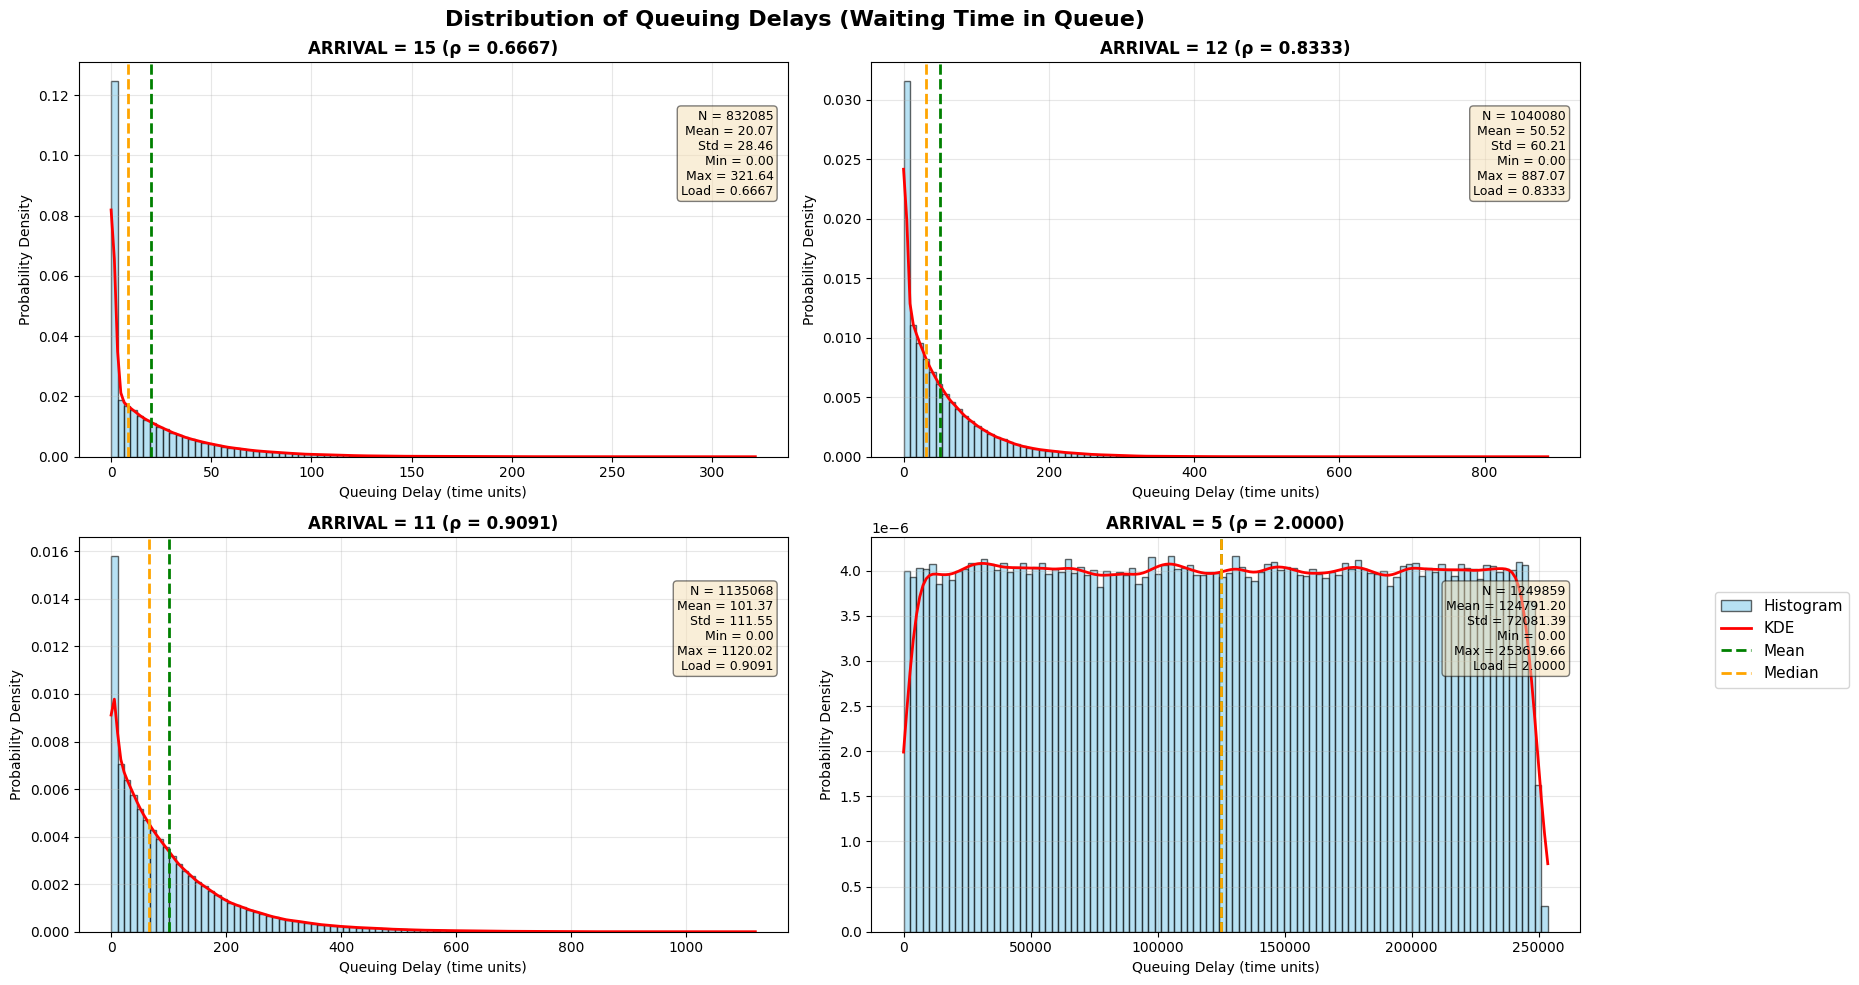

In [29]:
# Plot distribution of queuing delays
plot_results(all_results, ARRIVALS, SERVICE)
